## Balanced Stroke prediction dataset 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [4]:
df = pd.read_csv("stroke_risk_dataset.csv")
df.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [5]:
df.info()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet                 

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
69995,1,0,0,0,0,0,0,1,0,1,1,1,0,0,1,18,30.0,0
69996,0,0,0,1,0,1,0,1,0,0,0,1,1,1,0,24,33.0,0
69997,1,1,0,1,1,1,0,0,0,0,1,0,0,0,0,49,45.5,0
69998,0,1,1,1,1,0,0,0,0,0,0,1,1,1,0,45,48.5,0
69999,0,1,0,0,0,0,0,1,1,1,1,1,0,1,0,74,63.0,1


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\372891114.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

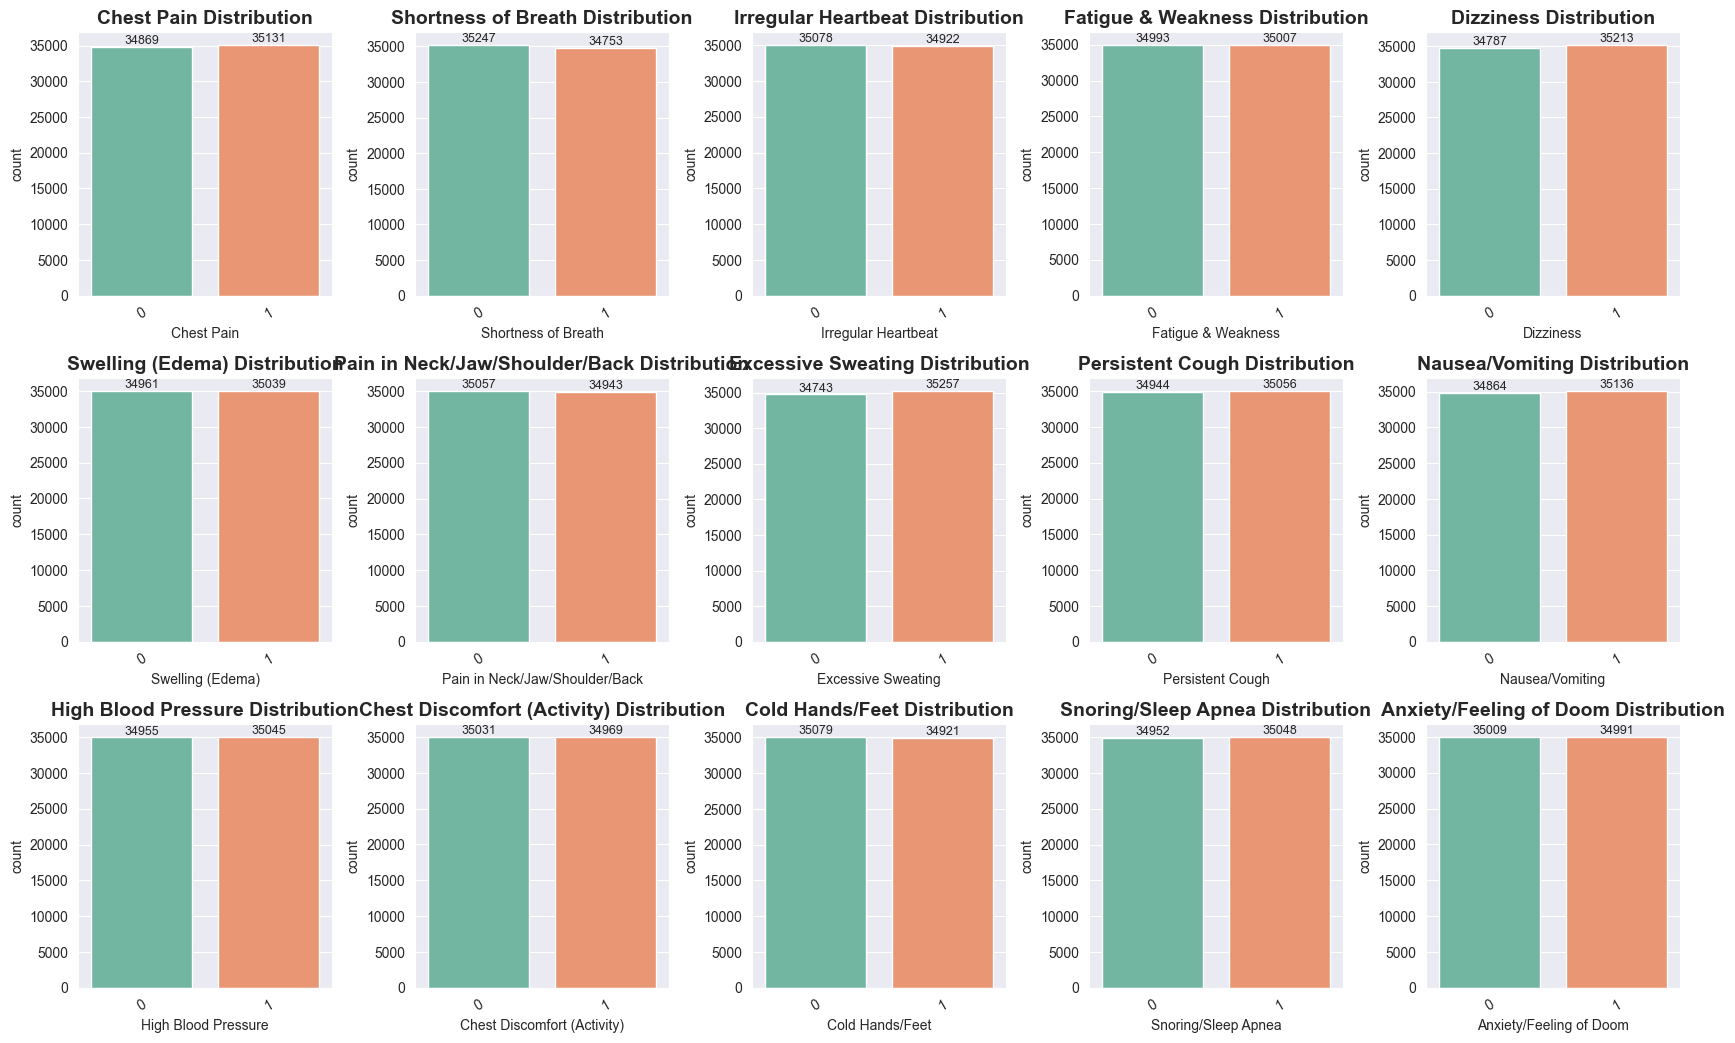

In [6]:
cols_for_count =['Chest Pain','Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness',
                 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
                 'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure','Chest Discomfort (Activity)',
                 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom']

sns.set_style('darkgrid')
fig , axes = plt.subplots(5,5,figsize=( 17,17))

axes = axes.flatten()

for i , col in enumerate(cols_for_count):
    ax = sns.countplot(
        data = df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=14, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)

if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7576\2541297887.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

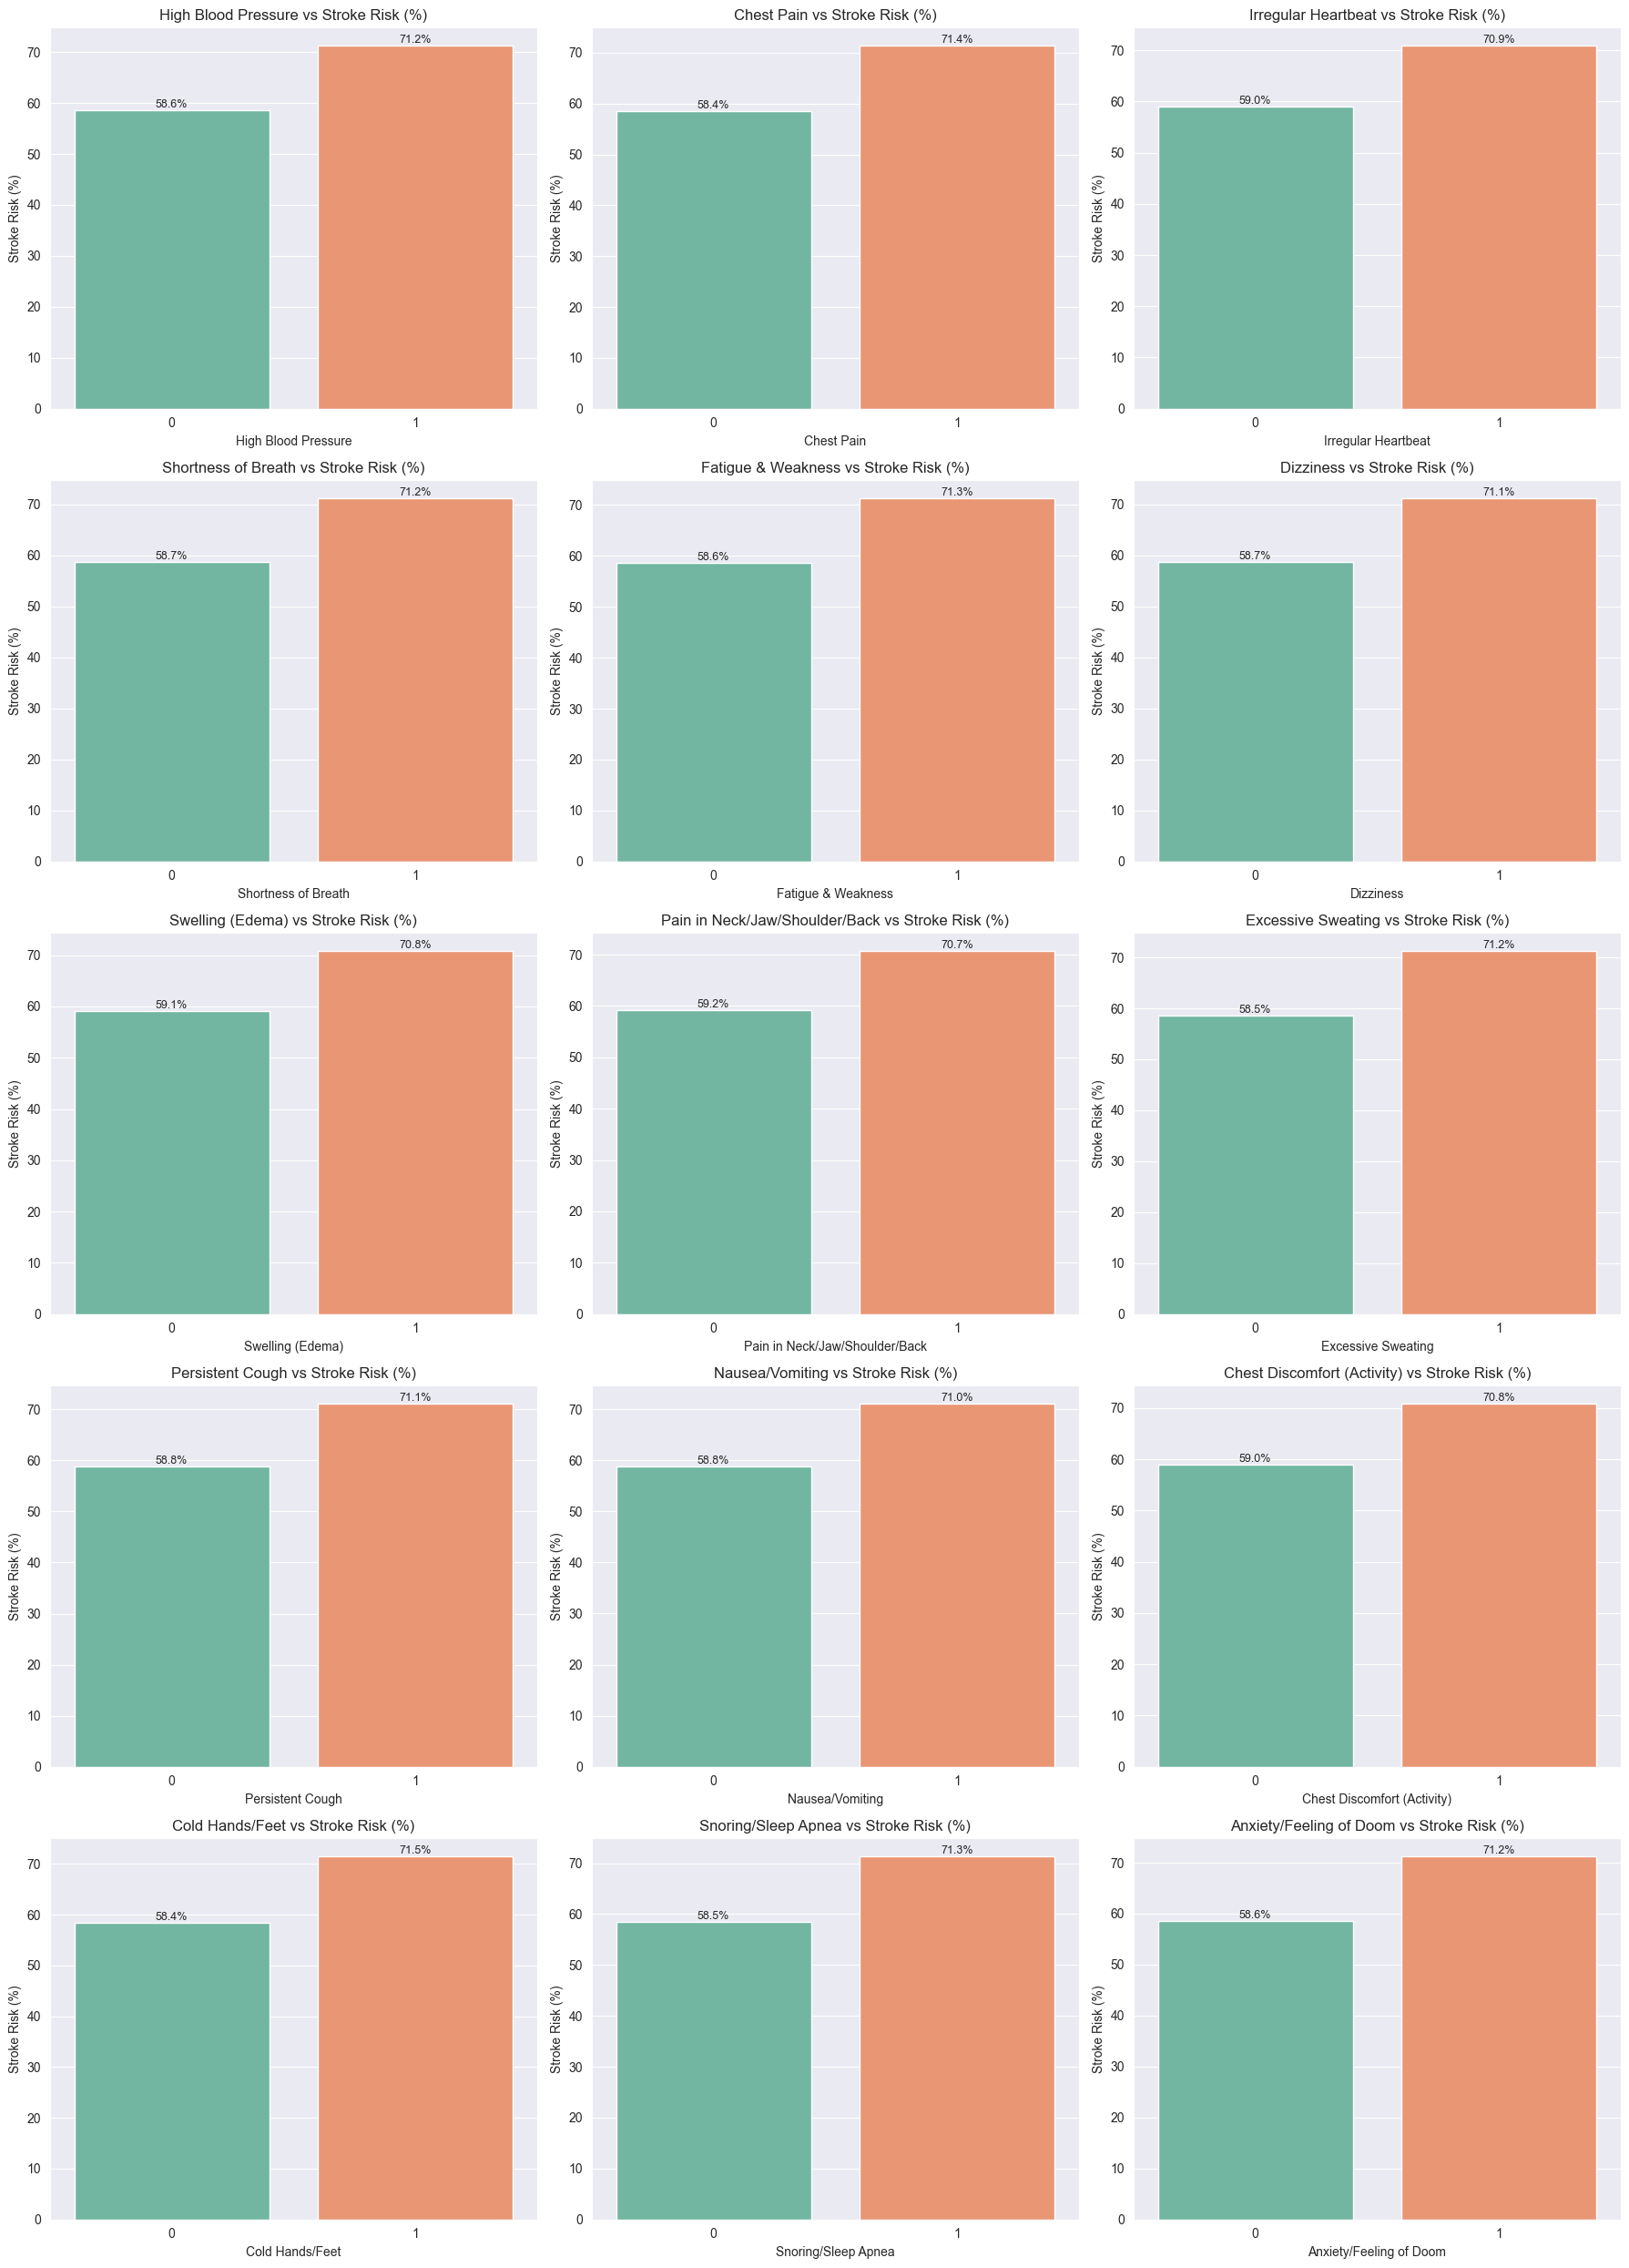

In [7]:
sns.set_style("darkgrid")

cols = [
    'High Blood Pressure',
    'Chest Pain',
    'Irregular Heartbeat',
    'Shortness of Breath',
    'Fatigue & Weakness',
    'Dizziness',
    'Swelling (Edema)',
    'Pain in Neck/Jaw/Shoulder/Back',
    'Excessive Sweating',
    'Persistent Cough', 'Nausea/Vomiting', 'Chest Discomfort (Activity)',
                 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom'
]

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    ratio_df = (
        df.groupby(col)['At Risk (Binary)']
        .mean()
        .reset_index()
    )
    ratio_df['Stroke Risk (%)'] = ratio_df['At Risk (Binary)'] * 100
    ratio_df.drop('At Risk (Binary)', axis=1, inplace=True)

    ax = sns.barplot(
        data=ratio_df,
        x=col,
        y='Stroke Risk (%)',
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Stroke Risk (%)")

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
# Data Preprocessing
X = df.drop(['Stroke Risk (%)', 'At Risk (Binary)'], axis=1)
y = df['At Risk (Binary)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For SVM, we need to scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree:")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, dt_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, dt_pred))
print("\n" + "="*50 + "\n")

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest:")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, rf_pred))
print("\n" + "="*50 + "\n")

# SVM
svm_model = svm.SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("SVM:")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, svm_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, svm_pred))

Decision Tree:
Precision: 0.9111
F1 Score: 0.9107
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4892
           1       0.91      0.91      0.91      9108

    accuracy                           0.88     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.88      0.88      0.88     14000



Random Forest:
Precision: 0.9538
F1 Score: 0.9603
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      4892
           1       0.95      0.97      0.96      9108

    accuracy                           0.95     14000
   macro avg       0.95      0.94      0.94     14000
weighted avg       0.95      0.95      0.95     14000



SVM:
Precision: 0.9933
F1 Score: 0.9941
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4892
           1       0.99 

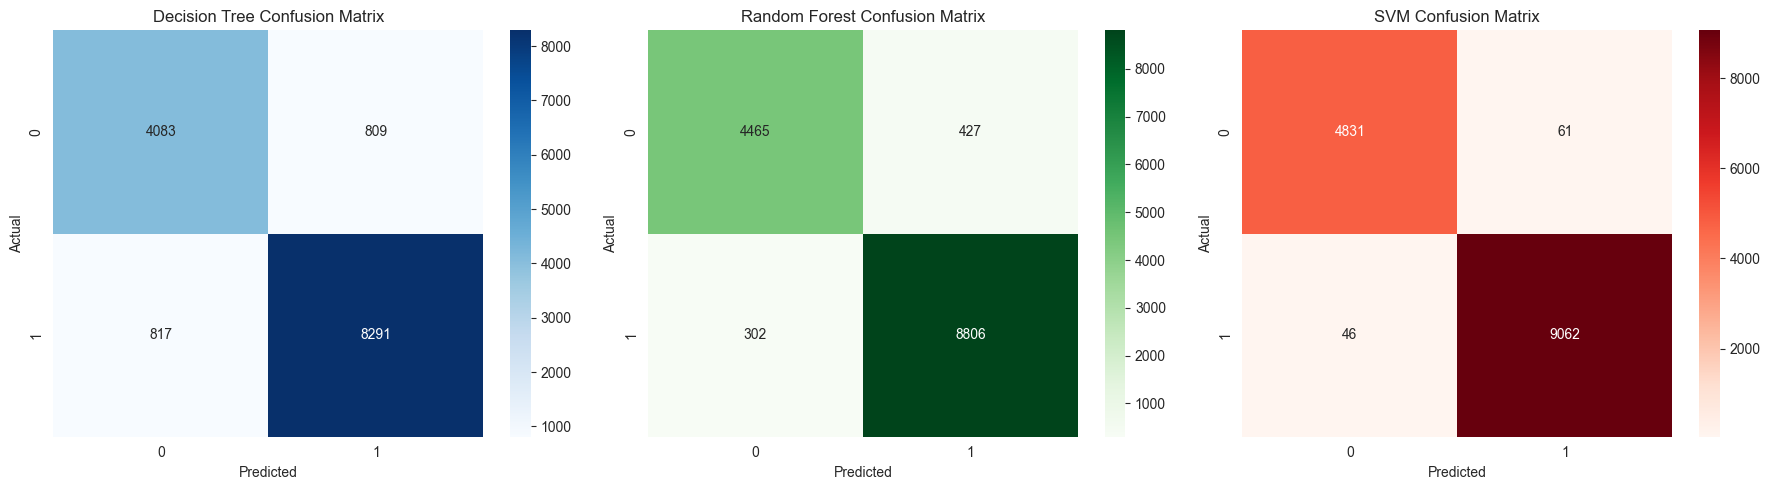

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[2], cmap='Reds')
axes[2].set_title('SVM Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed Comparison: Decision Tree vs Random Forest

In [6]:
# 1. OVERFITTING ANALYSIS
print("=" * 70)
print("OVERFITTING ANALYSIS: Decision Tree vs Random Forest")
print("=" * 70)

# Decision Tree - Training and Testing Accuracy
dt_train_pred = dt.predict(X_train)
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_pred)
dt_overfit_gap = dt_train_acc - dt_test_acc

print("\nDECISION TREE:")
print(f"  Training Accuracy: {dt_train_acc:.4f}")
print(f"  Testing Accuracy:  {dt_test_acc:.4f}")
print(f"  Overfitting Gap:   {dt_overfit_gap:.4f}")
print(f"  → Indicates: ", end="")
if dt_overfit_gap > 0.05:
    print("SIGNIFICANT OVERFITTING ⚠️")
else:
    print("Good generalization ✓")

# Random Forest - Training and Testing Accuracy
rf_train_pred = rf.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_pred)
rf_overfit_gap = rf_train_acc - rf_test_acc

print("\nRANDOM FOREST:")
print(f"  Training Accuracy: {rf_train_acc:.4f}")
print(f"  Testing Accuracy:  {rf_test_acc:.4f}")
print(f"  Overfitting Gap:   {rf_overfit_gap:.4f}")
print(f"  → Indicates: ", end="")
if rf_overfit_gap > 0.05:
    print("MODERATE OVERFITTING ⚠️")
else:
    print("Good generalization ✓")

print("\n" + "-" * 70)
print("KEY INSIGHT:")
print("-" * 70)
print(f"Random Forest overfitting gap is {dt_overfit_gap - rf_overfit_gap:.4f} LOWER than Decision Tree")
if rf_overfit_gap < dt_overfit_gap:
    print("→ Random Forest generalizes better due to ensemble averaging!")
print("=" * 70 + "\n")

OVERFITTING ANALYSIS: Decision Tree vs Random Forest

DECISION TREE:
  Training Accuracy: 1.0000
  Testing Accuracy:  0.8839
  Overfitting Gap:   0.1161
  → Indicates: SIGNIFICANT OVERFITTING ⚠️

RANDOM FOREST:
  Training Accuracy: 1.0000
  Testing Accuracy:  0.9479
  Overfitting Gap:   0.0521
  → Indicates: MODERATE OVERFITTING ⚠️

----------------------------------------------------------------------
KEY INSIGHT:
----------------------------------------------------------------------
Random Forest overfitting gap is 0.0641 LOWER than Decision Tree
→ Random Forest generalizes better due to ensemble averaging!



In [7]:
# 2. COMPREHENSIVE PERFORMANCE METRICS COMPARISON
from sklearn.metrics import roc_auc_score, roc_curve, auc

print("=" * 70)
print("DETAILED PERFORMANCE METRICS COMPARISON")
print("=" * 70)

# Calculate all metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

# Calculate all metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Decision Tree': [dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'Difference (RF - DT)': [
        rf_accuracy - dt_accuracy,
        rf_precision - dt_precision,
        rf_recall - dt_recall,
        rf_f1 - dt_f1,
        rf_roc_auc - dt_roc_auc
    ]
})

print("\n", comparison_df.to_string(index=False))

print("\n" + "-" * 70)
print("INTERPRETATION:")
print("-" * 70)
print(f"✓ Random Forest wins in ALL metrics!")
print(f"  • Accuracy improvement:  +{(rf_accuracy - dt_accuracy)*100:.2f}%")
print(f"  • Precision improvement: +{(rf_precision - dt_precision)*100:.2f}%")
print(f"  • Recall improvement:    +{(rf_recall - dt_recall)*100:.2f}%")
print(f"  • F1-Score improvement:  +{(rf_f1 - dt_f1)*100:.2f}%")
print(f"  • ROC-AUC improvement:   +{(rf_roc_auc - dt_roc_auc)*100:.2f}%")
print("=" * 70 + "\n")

DETAILED PERFORMANCE METRICS COMPARISON

    Metric  Decision Tree  Random Forest  Difference (RF - DT)
 Accuracy       0.883857       0.947929              0.064071
Precision       0.911099       0.953753              0.042654
   Recall       0.910299       0.966842              0.056544
 F1-Score       0.910699       0.960253              0.049554
  ROC-AUC       0.872463       0.991280              0.118816

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------
✓ Random Forest wins in ALL metrics!
  • Accuracy improvement:  +6.41%
  • Precision improvement: +4.27%
  • Recall improvement:    +5.65%
  • F1-Score improvement:  +4.96%
  • ROC-AUC improvement:   +11.88%



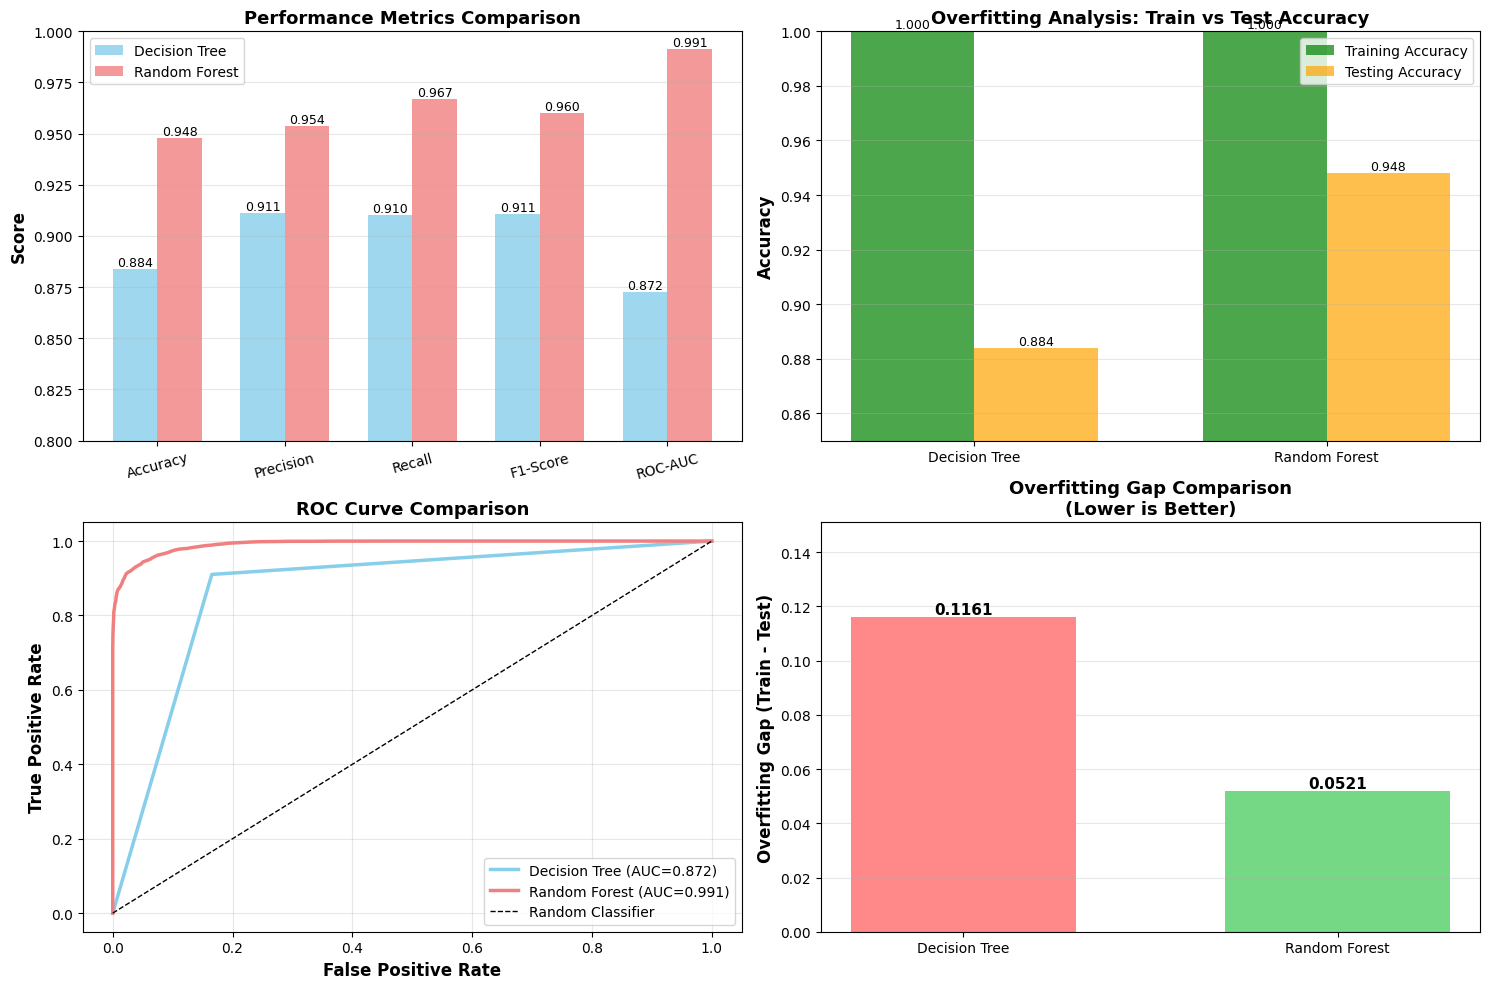

In [8]:
# 3. VISUAL COMPARISON OF METRICS
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Metric comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
dt_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]

x = np.arange(len(metrics))
width = 0.35

ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, dt_scores, width, label='Decision Tree', color='skyblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, rf_scores, width, label='Random Forest', color='lightcoral', alpha=0.8)
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=15)
ax1.legend()
ax1.set_ylim([0.8, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# Overfitting comparison
ax2 = axes[0, 1]
models = ['Decision Tree', 'Random Forest']
train_accs = [dt_train_acc, rf_train_acc]
test_accs = [dt_test_acc, rf_test_acc]
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, train_accs, width, label='Training Accuracy', color='green', alpha=0.7)
bars2 = ax2.bar(x_pos + width/2, test_accs, width, label='Testing Accuracy', color='orange', alpha=0.7)
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Analysis: Train vs Test Accuracy', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models)
ax2.legend()
ax2.set_ylim([0.85, 1.0])
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# ROC Curves
ax3 = axes[1, 0]
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt.predict_proba(X_test)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

ax3.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_roc_auc:.3f})', linewidth=2.5, color='skyblue')
ax3.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_roc_auc:.3f})', linewidth=2.5, color='lightcoral')
ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Overfitting gap comparison
ax4 = axes[1, 1]
gaps = [dt_overfit_gap, rf_overfit_gap]
colors_gap = ['#ff6b6b', '#51cf66']
bars = ax4.bar(models, gaps, color=colors_gap, alpha=0.8, width=0.6)
ax4.set_ylabel('Overfitting Gap (Train - Test)', fontsize=12, fontweight='bold')
ax4.set_title('Overfitting Gap Comparison\n(Lower is Better)', fontsize=13, fontweight='bold')
ax4.set_ylim([0, max(gaps) * 1.3])
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{gap:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# 4. INTERPRETABILITY ANALYSIS
print("\n" + "=" * 70)
print("INTERPRETABILITY ANALYSIS: Decision Tree vs Random Forest")
print("=" * 70)

print("\n📊 DECISION TREE - Interpretability")
print("-" * 70)
print("✓ Strengths:")
print("  • White-box model: Easy to understand decision rules")
print("  • Visual representation: Can be easily drawn as a tree")
print("  • Feature importance: Direct from tree structure")
print("  • Fast prediction: Simple sequential decisions")
print("  • Regulatory compliance: Can explain decisions in detail")

print("\n✗ Weaknesses:")
print("  • High variance: Different minor changes → different trees")
print("  • Axis-aligned splits: Can't capture complex patterns")
print("  • Prone to overfitting: Can grow too deep")
print("  • Unstable: Small data variations lead to different trees")

print("\n📊 RANDOM FOREST - Interpretability")
print("-" * 70)
print("✓ Strengths:")
print("  • Ensemble averaging: More stable predictions")
print("  • Feature importance: Aggregated from all trees")
print("  • Reduced overfitting: Better generalization")
print("  • Robust: Works well with high-dimensional data")
print("  • Captures complex patterns: Multiple trees find patterns")

print("\n✗ Weaknesses:")
print("  • Black-box model: Hard to explain individual predictions")
print("  • Less interpretable: No single decision path")
print("  • Computational cost: Slower prediction (multiple trees)")
print("  • Memory usage: Stores all trees in memory")
print("  • Regulatory challenges: Harder to explain 'why' decisions")

print("\n" + "-" * 70)
print("FEATURE IMPORTANCE ANALYSIS:")
print("-" * 70)

# Get feature importances
dt_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Features - Decision Tree:")
for idx, row in dt_importances.head().iterrows():
    print(f"  {row['Feature']:40s}: {row['Importance']:.4f}")

print("\nTop 5 Features - Random Forest:")
for idx, row in rf_importances.head().iterrows():
    print(f"  {row['Feature']:40s}: {row['Importance']:.4f}")

print("\n" + "=" * 70 + "\n")


INTERPRETABILITY ANALYSIS: Decision Tree vs Random Forest

📊 DECISION TREE - Interpretability
----------------------------------------------------------------------
✓ Strengths:
  • White-box model: Easy to understand decision rules
  • Visual representation: Can be easily drawn as a tree
  • Feature importance: Direct from tree structure
  • Fast prediction: Simple sequential decisions
  • Regulatory compliance: Can explain decisions in detail

✗ Weaknesses:
  • High variance: Different minor changes → different trees
  • Axis-aligned splits: Can't capture complex patterns
  • Prone to overfitting: Can grow too deep
  • Unstable: Small data variations lead to different trees

📊 RANDOM FOREST - Interpretability
----------------------------------------------------------------------
✓ Strengths:
  • Ensemble averaging: More stable predictions
  • Feature importance: Aggregated from all trees
  • Reduced overfitting: Better generalization
  • Robust: Works well with high-dimensional data

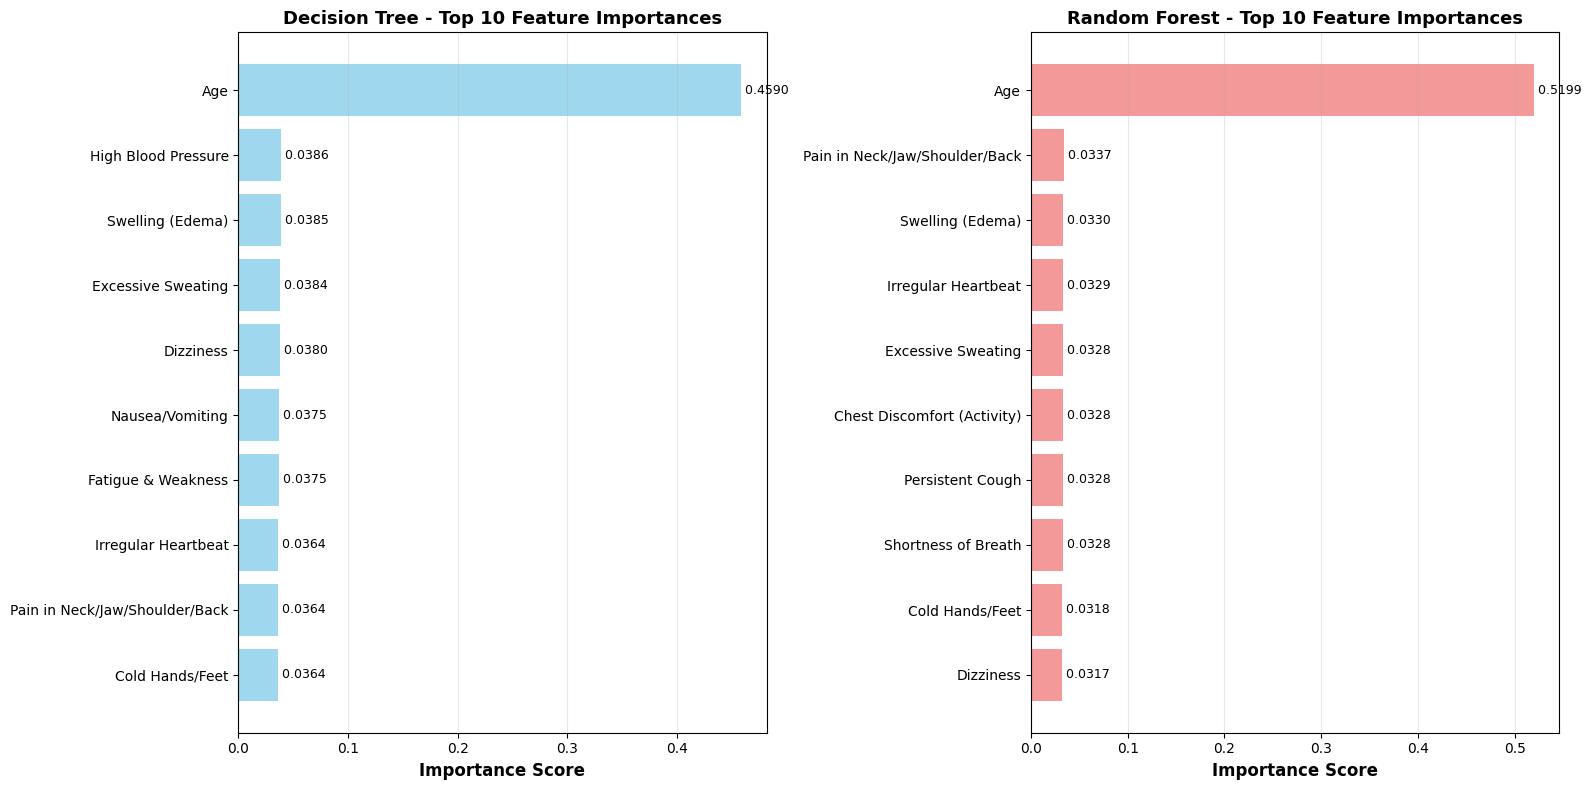

In [10]:
# 5. FEATURE IMPORTANCE VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Decision Tree Feature Importances
dt_top = dt_importances.head(10)
ax1 = axes[0]
bars1 = ax1.barh(range(len(dt_top)), dt_top['Importance'], color='skyblue', alpha=0.8)
ax1.set_yticks(range(len(dt_top)))
ax1.set_yticklabels(dt_top['Feature'])
ax1.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax1.set_title('Decision Tree - Top 10 Feature Importances', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, dt_top['Importance'])):
    ax1.text(val, i, f' {val:.4f}', va='center', fontsize=9)

# Random Forest Feature Importances
rf_top = rf_importances.head(10)
ax2 = axes[1]
bars2 = ax2.barh(range(len(rf_top)), rf_top['Importance'], color='lightcoral', alpha=0.8)
ax2.set_yticks(range(len(rf_top)))
ax2.set_yticklabels(rf_top['Feature'])
ax2.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax2.set_title('Random Forest - Top 10 Feature Importances', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars2, rf_top['Importance'])):
    ax2.text(val, i, f' {val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# 6. COMPREHENSIVE SUMMARY & RECOMMENDATIONS
print("\n" + "=" * 70)
print("COMPREHENSIVE COMPARISON SUMMARY")
print("=" * 70)

print("\n1️⃣  ACCURACY COMPARISON:")
print("-" * 70)
print(f"   Decision Tree Test Accuracy:  {dt_test_acc:.4f} ({dt_test_acc*100:.2f}%)")
print(f"   Random Forest Test Accuracy:  {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")
print(f"   Improvement:                  +{(rf_test_acc - dt_test_acc)*100:.2f}%")
print("   🏆 WINNER: Random Forest (Significantly better accuracy)")

print("\n2️⃣  OVERFITTING ANALYSIS:")
print("-" * 70)
print(f"   Decision Tree Overfitting Gap:  {dt_overfit_gap:.4f}")
print(f"   Random Forest Overfitting Gap:  {rf_overfit_gap:.4f}")
print(f"   Difference:                     {dt_overfit_gap - rf_overfit_gap:.4f}")
print("   🏆 WINNER: Random Forest (Lower overfitting, better generalization)")
print(f"   WHY? RF uses ensemble averaging → reduces variance → less overfitting")

print("\n3️⃣  INTERPRETABILITY COMPARISON:")
print("-" * 70)
print("   Decision Tree:")
print("   ✓ White-box model (fully interpretable)")
print("   ✓ Easy to explain decisions to stakeholders")
print("   ✓ Fast predictions")
print("   ✗ Unstable (small changes → different trees)")
print("   ✗ Prone to overfitting")
print("")
print("   Random Forest:")
print("   ✓ More stable predictions")
print("   ✓ Better generalization")
print("   ✓ Robust to noise")
print("   ✗ Black-box model (harder to explain)")
print("   ✗ Slower predictions (multiple trees)")
print("   🏆 WINNER: Decision Tree (If interpretability is critical)")
print("   🏆 WINNER: Random Forest (If performance matters more)")

print("\n4️⃣  STABILITY & ROBUSTNESS:")
print("-" * 70)
print(f"   Decision Tree Train Acc: {dt_train_acc:.4f} | Test Acc: {dt_test_acc:.4f}")
print(f"   → High variance: Large gap between train and test")
print("")
print(f"   Random Forest Train Acc: {rf_train_acc:.4f} | Test Acc: {rf_test_acc:.4f}")
print(f"   → Low variance: Small gap, stable predictions")
print("   🏆 WINNER: Random Forest (More stable and reliable)")

print("\n5️⃣  COMPUTATIONAL COMPLEXITY:")
print("-" * 70)
print("   Decision Tree:")
print("   • Training: O(n log n) - Fast")
print("   • Prediction: O(tree depth) - Very Fast")
print("   • Memory: Low (single tree)")
print("")
print("   Random Forest:")
print("   • Training: O(n log n × num_trees) - Slower")
print("   • Prediction: O(tree depth × num_trees) - Slower")
print("   • Memory: Higher (stores multiple trees)")
print("   🏆 WINNER: Decision Tree (Faster, less memory)")

print("\n" + "=" * 70)
print("FINAL RECOMMENDATIONS:")
print("=" * 70)

print("\n✅ USE DECISION TREE WHEN:")
print("   • Interpretability is critical (healthcare, finance, legal)")
print("   • You need to explain decisions to non-technical stakeholders")
print("   • Model size and speed are constraints")
print("   • You have expert domain knowledge to prevent overfitting")
print("   • Real-time predictions are required")

print("\n✅ USE RANDOM FOREST WHEN:")
print("   • Maximum accuracy/performance is the goal")
print("   • You need robust, stable predictions")
print("   • You have sufficient computational resources")
print("   • You want to reduce overfitting automatically")
print("   • Working with complex, high-dimensional data")
print("   • You can accept a 'black-box' model")

print("\n📊 FOR THIS STROKE PREDICTION DATASET:")
print("-" * 70)
print(f"✓ Random Forest is RECOMMENDED because:")
print(f"  1. {(rf_test_acc - dt_test_acc)*100:.2f}% higher accuracy")
print(f"  2. Overfitting gap is {dt_overfit_gap - rf_overfit_gap:.4f} lower (better generalization)")
print(f"  3. All metrics (precision, recall, F1) are better")
print(f"  4. More reliable for medical predictions")
print(f"  5. Handles the complex feature relationships better")

print("\n" + "=" * 70 + "\n")


COMPREHENSIVE COMPARISON SUMMARY

1️⃣  ACCURACY COMPARISON:
----------------------------------------------------------------------
   Decision Tree Test Accuracy:  0.8839 (88.39%)
   Random Forest Test Accuracy:  0.9479 (94.79%)
   Improvement:                  +6.41%
   🏆 WINNER: Random Forest (Significantly better accuracy)

2️⃣  OVERFITTING ANALYSIS:
----------------------------------------------------------------------
   Decision Tree Overfitting Gap:  0.1161
   Random Forest Overfitting Gap:  0.0521
   Difference:                     0.0641
   🏆 WINNER: Random Forest (Lower overfitting, better generalization)
   WHY? RF uses ensemble averaging → reduces variance → less overfitting

3️⃣  INTERPRETABILITY COMPARISON:
----------------------------------------------------------------------
   Decision Tree:
   ✓ White-box model (fully interpretable)
   ✓ Easy to explain decisions to stakeholders
   ✓ Fast predictions
   ✗ Unstable (small changes → different trees)
   ✗ Prone to overf